In [ ]:
from pathlib import Path
import json

import pandas as pd
import numpy as np


run_dir = Path(".").resolve() / "runs"
figures_folder = Path(".").resolve() / "paper" / "figures"

names = [
    "exp_scaling_742fde19a2_Cifar10_20260907_145449",
    "exp_scaling_4f767e649d_Bikes_20260907_172915",
    "exp_scaling_1b88e205dd_Svhn_20260907_182603",
    "exp_scaling_2f7815bfc8_Energy_20260907_214458",
]


def parse_value(value):
    try:
        return int(value)
    except ValueError:
        return value


def parse_stem(path, suffix: str ="_metrics"):
    stem = path.stem.removesuffix(suffix)
    parts = stem.split("_")

    if len(parts) % 2 != 0:
        raise ValueError(f"Expected key_value pairs, got: {path.name}")

    return {
        parts[i]: parse_value(parts[i + 1])
        for i in range(0, len(parts), 2)
    }


In [36]:
dfs = []

for name in names:
    exp_dir = run_dir / name
    metric_files = sorted(exp_dir.glob("*_metrics.json"))

    parse_name = name.replace("ambiguity_gradient", "gradient")

    _, exp_type, launch_id, task, t1, t2 = parse_name.split("_")

    for path in metric_files:
        info = parse_stem(path)

        with path.open() as f:

            try:
                metrics = json.load(f)
            except json.JSONDecodeError:
                print(f"Cannot decode {path}")
                continue

        metrics = {
            k: np.asarray(v)
            for k, v in metrics.items()
        }

        shapes = {k: v.shape for k, v in metrics.items()}

        if len(set(shapes.values())) != 1:
            raise ValueError(
                f"Metric shapes differ in {path.name}: {shapes}"
            )

        shape = next(iter(shapes.values()))

        if len(shape) != 2:
            raise ValueError(
                f"Expected metrics shaped (epoch, seed), got {shape} "
                f"in {path.name}"
            )

        n_epochs, n_seeds = shape

        # Flatten in row-major order:
        # epoch 0 seed 0..N, epoch 1 seed 0..N, ...
        metrics_df = pd.DataFrame({
            k: v.reshape(-1)
            for k, v in metrics.items()
        })

        metrics_df["epoch"] = np.repeat(
            np.arange(n_epochs),
            n_seeds,
        )

        metrics_df["seed_id"] = np.tile(
            np.arange(n_seeds),
            n_epochs,
        )

        metrics_df["run_id"] = info.pop("run")
        metrics_df["task"] = task


        for key, value in info.items():
            metrics_df[key] = value

        # metrics_df["experiment"] = name

        dfs.append(metrics_df)


df = pd.concat(dfs, ignore_index=True)

df: pd.DataFrame = df.sort_values(
    ["run_id", "seed_id", "epoch"]
).reset_index(drop=True)

def mean_seeds(df: pd.DataFrame):
    from pandas.api.types import is_string_dtype

    mean_columns = tuple(df.dtypes.index[df.dtypes == float])
    take_columns = tuple((set(df.dtypes.index[df.dtypes == int]) | set(df.dtypes.index[df.dtypes.apply(is_string_dtype)])) - {"seed_id"})

    group_cols = ["task", "epoch", "run_id"]
    take_columns = tuple(set(take_columns) - set(group_cols))
    mean_columns = tuple(set(mean_columns) - set(group_cols))

    print(f"Averaging {mean_columns} columns")

    g = df.groupby(group_cols, observed=True)

    nunique = g[list(take_columns)].nunique(dropna=False)
    assert (nunique <= 1).all().all(), f"Non-unique values:\n{nunique[nunique.gt(1).any(axis=1)]}"

    return g.agg(
        **{c: (c, "mean") for c in mean_columns},
        **{c: (c, "first") for c in take_columns},
    ).reset_index()

df: pd.DataFrame = df.pipe(mean_seeds)

Averaging ('r2_metric', 'validation_load_balancing_loss', 'validation_r2_metric', 'validation_accuracy_metric', 'validation_loss', 'load_balancing_loss', 'validation_performance_loss', 'performance_loss', 'loss', 'accuracy_metric') columns


In [ ]:
def norm_entropy(x, axis, normalize: bool = False):
    x = np.asarray(x, dtype=float)
    n = x.shape[axis]

    if n == 0:
        return np.full(x.sum(axis=axis).shape, np.nan)

    assert np.all(np.isfinite(x)) and np.all(x >= 0)

    if normalize:
        x = x / np.sum(x, axis=axis, keepdims=True)
    else:
        assert np.all(np.isclose(x.sum(axis=axis), 1.0, atol=1e-5)), x.sum(axis=axis)

    if n == 1:
        return np.full(x.sum(axis=axis).shape, np.inf)

    log_x = np.zeros_like(x)
    np.log(x, out=log_x, where=x > 0)

    return -np.sum(x * log_x, axis=axis) / np.log(n)

df_metrics = []

for name in names:
    exp_dir = run_dir / name
    metric_files = sorted(exp_dir.glob("*eval_metrics.npz"))

    parse_name = name.replace("ambiguity_gradient", "gradient")

    _, exp_type, launch_id, task, t1, t2 = parse_name.split("_")

    rows = []
    for path in metric_files:
        info = parse_stem(path, suffix="_eval_metrics")

        try:
            with np.load(path) as metrics:

                if "predictors_weight_per_model" not in metrics:
                    assert info["delegators"] == 0, f"Metrics do not contain predictors_weight_per_model but delegators is {info['delegators']}"
                    row = info | dict(
                            weights_entropy=np.nan,
                            delegators_ambiguity=np.nan,
                            delegators_performance=np.nan,
                            predictors_ambiguity=np.nan,
                            predictors_performance=np.nan,
                            predictor_loss_entropy=np.nan,
                            delegators_loss_entropy=np.nan,
                            final_loss=np.nan,
                            final_loss_under_oracle=np.nan,
                            final_metric=np.nan,
                            final_metric_under_oracle=np.nan,
                        )
                    rows.append(row)
                    continue

                predictors_weight_per_model = metrics["predictors_weight_per_model"]
                predictors_perfomance_per_model = metrics["predictors_perfomance_per_model"]
                predictors_ambiguity_per_model = metrics["predictors_ambiguity_per_model"]
                delegators_perfomance_per_model = metrics["delegators_perfomance_per_model"]
                delegators_ambiguity_per_model = metrics["delegators_ambiguity_per_model"]

                loss = metrics["loss"]
                loss_under_oracle = metrics["loss_under_oracle"]
                metric = metrics["metric"]
                metric_under_oracle = metrics["metric_under_oracle"]
        except EOFError:
            print(f"Empty file {path}")
            continue

        predictors_performance = np.mean(predictors_perfomance_per_model * predictors_weight_per_model, axis=1)
        mean_predictors_performance = np.mean(np.sum(predictors_performance, axis=-1))
        predictor_loss_entropy = np.mean(norm_entropy(predictors_performance, axis=-1, normalize=True))

        mean_predictors_ambiguity = np.mean(np.sum(predictors_ambiguity_per_model * predictors_weight_per_model, axis=-1))
    
        weights_entropy = np.mean(norm_entropy(predictors_weight_per_model, axis=-1)) 

        mean_delegators_performance = np.mean(delegators_perfomance_per_model)
        delegators_loss_entropy = np.mean(norm_entropy(np.mean(delegators_perfomance_per_model, axis=1), axis=-1, normalize=True))
        mean_delegators_ambiguity = np.mean(delegators_ambiguity_per_model)

        row = info | dict(
            weights_entropy=weights_entropy,
            delegators_ambiguity=mean_delegators_ambiguity,
            delegators_performance=mean_delegators_performance,
            predictors_ambiguity=mean_predictors_ambiguity,
            predictors_performance=mean_predictors_performance,
            predictor_loss_entropy=predictor_loss_entropy,
            delegators_loss_entropy=delegators_loss_entropy,
            final_loss=np.mean(loss),
            final_loss_under_oracle=np.mean(loss_under_oracle),
            final_metric=np.mean(metric),
            final_metric_under_oracle=np.mean(metric_under_oracle),
        )

        rows.append(row)
        
    temp = pd.DataFrame(rows)
    temp["task"] = task
    
    df_metrics.append(temp)

df_metrics: pd.DataFrame = pd.concat(df_metrics, ignore_index=True).rename(columns={"run": "run_id"})
df_metrics["final_loss_better"] = df_metrics["final_loss_under_oracle"]
mask = df_metrics["final_loss_better"] > df_metrics["final_loss"]
df_metrics.loc[mask, "final_loss_better"] = df_metrics.loc[mask, "final_loss"]
df_metrics["regret"] = (df_metrics["final_loss"] - df_metrics["final_loss_better"]) # / df_metrics["final_loss"]

In [93]:
task_baseline_losses = (
    df
    .groupby("task")["performance_loss"].quantile(0.99)
)

baseline = df["task"].map(task_baseline_losses)

df["performance_loss_casted"] = df["performance_loss"] / baseline
df["validation_performance_loss_casted"] = (
    df["validation_performance_loss"] / baseline
)

df["val_metric"] = df["validation_accuracy_metric"]
_nan_mask = df["val_metric"].isnull()
df.loc[_nan_mask, "val_metric"] = df.loc[_nan_mask, "validation_r2_metric"]
assert not df["val_metric"].isnull().any()

task_baseline_losses

task
Bikes      0.108731
Cifar10    1.890735
Energy     0.696621
Svhn       2.119888
Name: performance_loss, dtype: float64

In [ ]:
exp_vars = ["predictors", "pwidth", "dwidth"]
val_loss_col = "validation_performance_loss"
var_oi = "delegators"
var_oi_values = np.sort(df[var_oi].unique())
train_loss_col = "performance_loss"
higher_better = False

def get_metric_col(task):
    if task in {"Cifar10", "Svhn"}:
        return "validation_accuracy_metric"
    elif task in {"Bikes", "Energy"}:
        return "validation_r2_metric" 
    else:
        raise ValueError(f"Unknown task {task}")

In [94]:
from typing import Literal

from matplotlib import pyplot as plt


def select_last(df: pd.DataFrame):
    return (
        df
        .sort_values(["task", "run_id", "epoch"])
        .groupby(["task", "run_id"])
        .tail(1)
    )


def select_early_stopping(
    df: pd.DataFrame,
    min_epoch_portion: float | None = 0.1,
):
    if min_epoch_portion is not None:
        max_epoch = df.groupby("task")["epoch"].transform("max")
        df = df[df["epoch"] >= min_epoch_portion * max_epoch]

    idx = (
        df
        .groupby(["task", "run_id"])[val_loss_col]
        .idxmin()
    )
    return df.loc[idx].copy()


def add_metrics(df: pd.DataFrame):

    common_cols = list(set(df.columns) & set(df_metrics.columns))
    df_merged = pd.merge(df, df_metrics, "left", on=common_cols, validate="1:1")
    return df_merged

def pivot_to_metrics(paired: pd.DataFrame, *cols: str):

    cols = list(cols)

    if len(cols) == 0:
        cols = [val_loss_col]

    if len(cols) == 1:
        cols = cols[0]

    return pd.pivot(paired, index="pair_id", columns=var_oi, values=cols)


def scale_up_fonts(fig, scale: float = 1.3):


    for ax in fig.axes:
        ax.title.set_fontsize(ax.title.get_fontsize() * scale)
        ax.xaxis.label.set_fontsize(ax.xaxis.label.get_fontsize() * scale)
        ax.yaxis.label.set_fontsize(ax.yaxis.label.get_fontsize() * scale)

        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontsize(label.get_fontsize() * scale)

        legend = ax.get_legend()
        if legend is not None:
            for text in legend.get_texts():
                text.set_fontsize(text.get_fontsize() * scale)

    for legend in fig.legends:
        for text in legend.get_texts():
            text.set_fontsize(text.get_fontsize() * scale)



In [83]:
def plot_relative_diff(
    pivot: pd.DataFrame,
    ax,
    lw: int = 2,
):
    from itertools import combinations

    data = []
    labels = []

    for l, r in combinations(var_oi_values, 2):
        l_vals = pivot[l]
        r_vals = pivot[r]

       
        diff = l_vals - r_vals
       
        diff = diff.dropna()
        mean_diff = diff.mean()

        if mean_diff == 0:
            better = "tie"
        elif not higher_better:
            better = l if mean_diff < 0 else r
        else:
            better = l if mean_diff > 0 else r

        data.append(diff)

        labels.append(
            f"{l} − {r}\n"
            f"'{better}' better"
        )

    ax.boxplot(
        data,
        vert=False,
        tick_labels=labels,
        widths=0.6,
        showmeans=True,
        meanline=True,
        boxprops={"linewidth": lw},
        whiskerprops={"linewidth": lw},
        capprops={"linewidth": lw},
        medianprops={"linewidth": lw},
        meanprops={"linewidth": lw, "linestyle": "--"},
    )

    ax.axvline(0, color="black", linestyle="dashed")

    if (not higher_better):
        ax.set_xlabel(
            "← Left better  | Right better →"
        )
    else:
        ax.set_xlabel(
            "← Right better | Left better →"
        )


def delegators_xaxis(ax):
    ax.set_xscale(
        "symlog",
        base=2,
        linthresh=1,
        linscale=0.5,
    )
    ax.set_xticks(var_oi_values, var_oi_values)


LS = np.sort(df["delegators"].unique()).astype(int)
TASKS = np.sort(df["task"].unique())

def setup(ax):ax.axhline(0,color='0.55',lw=.7,zorder=0);ax.grid(axis='y',alpha=.15)
def xaxis(ax,zero=True):
 ax.set_xticks(range(7) if zero else range(1,7))
 ax.set_xticklabels(LS if zero else LS[1:])
 ax.tick_params(axis='x')
 ax.set_xlabel('Delegators $L$')


def aggregate_lines_with_base(
    run_task: pd.DataFrame,
    metric_col: str,
    delegators_base: int = 1,
    relative: bool = True,
    mid_mean: bool = True,
    reverse_diff: bool = False,
):

    run_task = run[run["task"] == task].copy()

    base = (
        run_task[run_task[var_oi] == delegators_base]
        .set_index(exp_vars)[metric_col]
    )

    run_task["base"] = run_task.set_index(exp_vars).index.map(base)

    relative_col = f"relative_{metric_col}"

    if relative:
        run_task[relative_col] = (
            run_task[metric_col] - run_task["base"]
        ) / run_task["base"]
    else:
        run_task[relative_col] = (
            run_task[metric_col] - run_task["base"]
        )

    if reverse_diff:
        run_task[relative_col] = -run_task[relative_col]

    grouped = run_task.groupby(var_oi)[relative_col]

    if mid_mean:
        mid = grouped.mean().reindex(var_oi_values)
    else:
        mid = grouped.median().reindex(var_oi_values)
    low = grouped.quantile(0.25).reindex(var_oi_values)
    high = grouped.quantile(0.75).reindex(var_oi_values)

    return low, mid, high


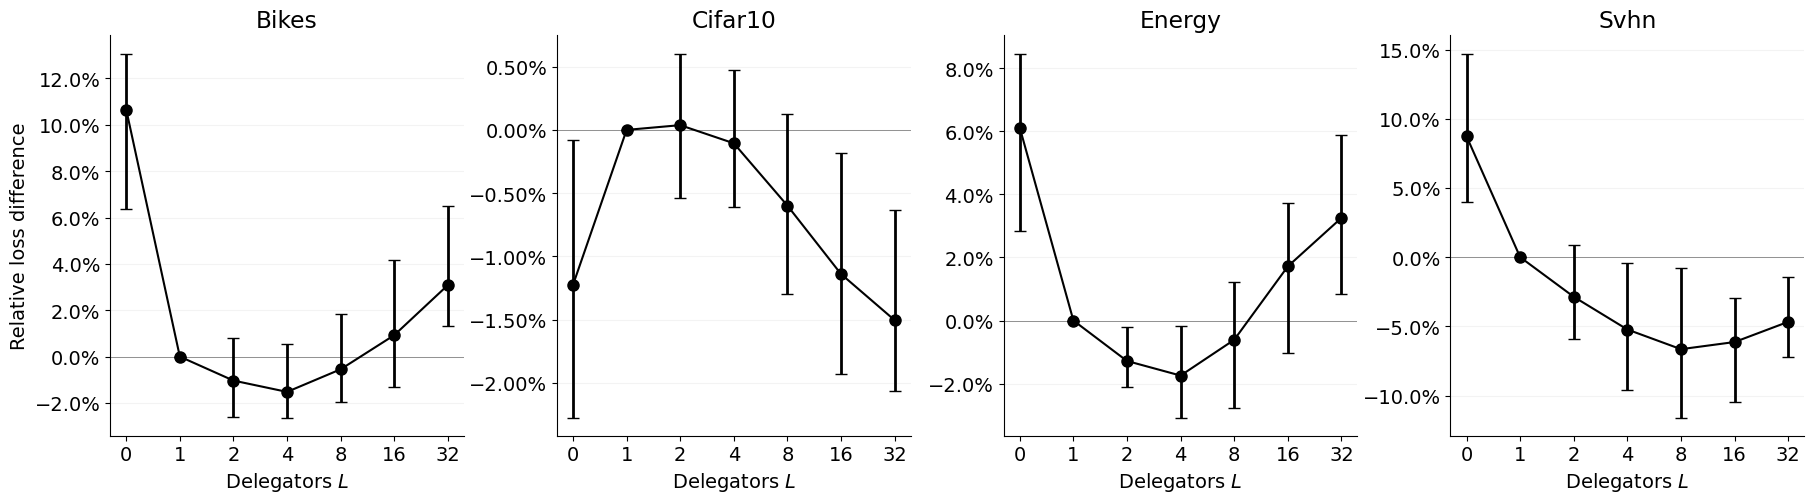

In [ ]:
from matplotlib.ticker import PercentFormatter

early_stopping = True

if early_stopping:
    run = df.pipe(select_early_stopping)
else:
    run = df.pipe(select_last)

fig, axs = plt.subplots(1, len(TASKS), sharey=False, figsize=(18, 5))

axs[0].set_ylabel("Relative loss difference")

for ax, task in zip(axs.flat, TASKS):
    setup(ax)
    xaxis(ax)
    ax.spines[["right", "top"]].set_visible(False)
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))

    run_task = run[run["task"] == task]

    low, mean, high = aggregate_lines_with_base(run_task, val_loss_col)

    yerr = np.vstack([mean - low, high - mean])

    x = np.arange(len(var_oi_values))

    ax.plot(x, mean, marker="o", color="black", lw=1.5, ms=8)
    ax.errorbar(x, mean, yerr=yerr, fmt="o", capsize=4, lw=2, color="black")
    ax.set_title(task.capitalize())

fig.tight_layout(w_pad=2.0)
scale_up_fonts(fig, scale=1.4)

fig.savefig(
    figures_folder / f"{exp_type}_line_validation_plot_{'early' if early_stopping else 'last'}.pdf"
)

## Individual predictor evaluation

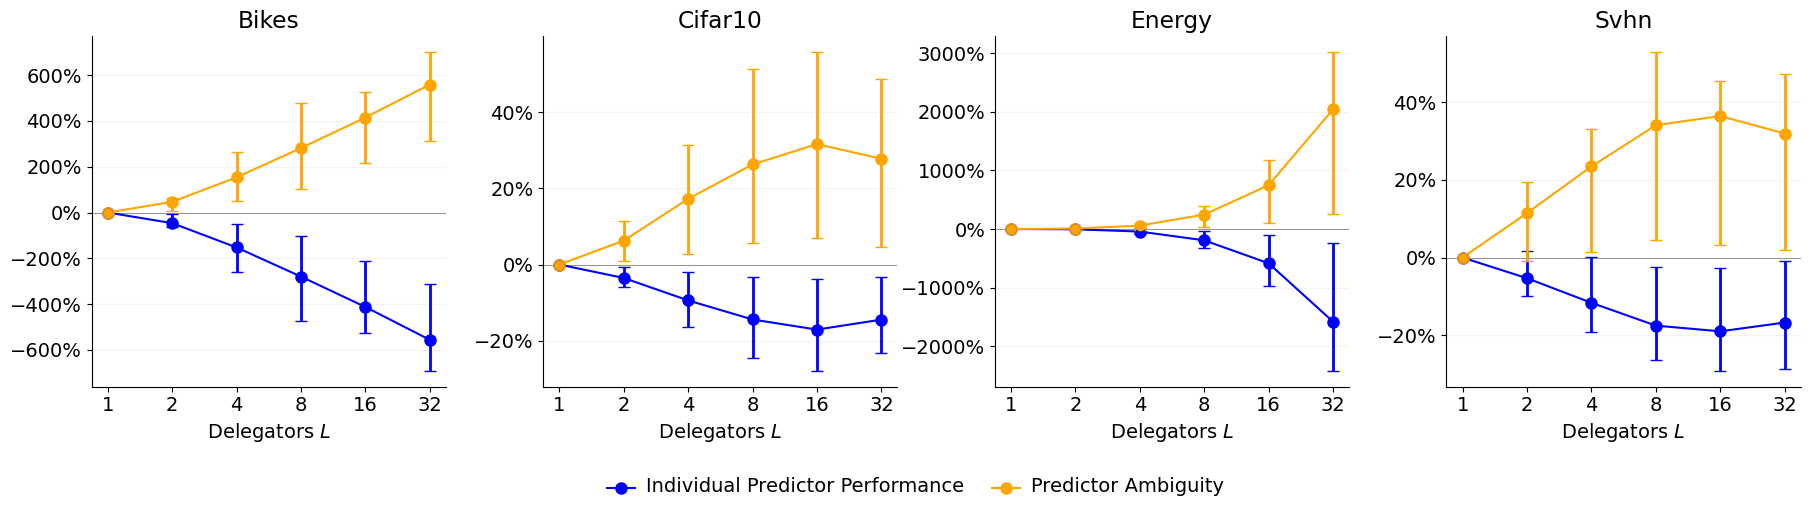

In [ ]:
early_stopping = True
relative = True

run = (
    df
    .pipe(select_early_stopping if early_stopping else select_last)
    .pipe(add_metrics)
)

fig, axs = plt.subplots(1, len(TASKS), sharey=False, figsize=(18, 5))

# axs[0].set_ylabel("Delegators' regret difference")

for ax, task in zip(axs.flat, TASKS):
    setup(ax)
    xaxis(ax)
    ax.spines[["right", "top"]].set_visible(False)

    if relative:
        ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))

    x = np.arange(len(var_oi_values))
    run_task = run[run["task"] == task]

    low, mean, high = aggregate_lines_with_base(run_task, "predictors_performance", relative=relative, mid_mean=True, reverse_diff=True)
    yerr = np.vstack([mean - low, high - mean])
    ax.plot(x, mean, marker="o", color="blue", lw=1.5, ms=8, label="Individual Predictor Performance")
    ax.errorbar(x, mean, yerr=yerr, fmt="o", capsize=4, lw=2, color="blue")

    low, mean, high = aggregate_lines_with_base(run_task, "predictors_ambiguity", relative=relative, mid_mean=True)
    yerr = np.vstack([mean - low, high - mean])
    ax.plot(x, mean, marker="o", color="orange", lw=1.5, ms=8, label="Predictor Ambiguity")
    ax.errorbar(x, mean, yerr=yerr, fmt="o", capsize=4, lw=2, color="orange")

    ax.set_title(task.capitalize())

handles, labels = axs.flat[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=2,
    frameon=False,
)

fig.tight_layout(w_pad=2.0, rect=[0, 0.10, 1, 1])
scale_up_fonts(fig, scale=1.4)

fig.savefig(
    figures_folder / "{exp_type}_2dline_predictors_ambiguity_performance.pdf"
)

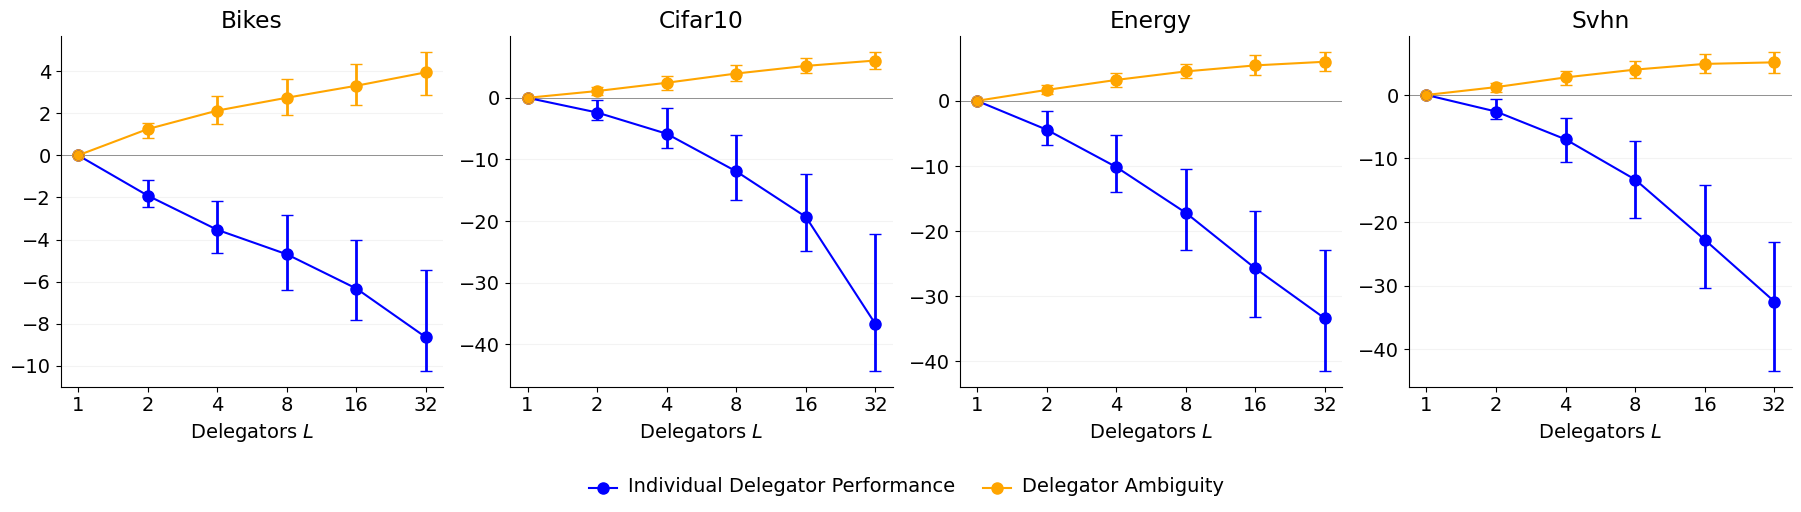

In [ ]:
early_stopping = True
relative = False
mid_mean = True
run = (
    df
    .pipe(select_early_stopping if early_stopping else select_last)
    .pipe(add_metrics)
)

fig, axs = plt.subplots(1, len(TASKS), sharey=False, figsize=(18, 5))

# axs[0].set_ylabel("Delegators' regret difference")

for ax, task in zip(axs.flat, TASKS):
    setup(ax)
    xaxis(ax)
    ax.spines[["right", "top"]].set_visible(False)

    if relative:
        ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))

    x = np.arange(len(var_oi_values))
    run_task = run[run["task"] == task]

    low, mean, high = aggregate_lines_with_base(run_task, "delegators_performance", relative=relative, mid_mean=mid_mean, reverse_diff=True)
    yerr = np.vstack([mean - low, high - mean])
    ax.plot(x, mean, marker="o", color="blue", lw=1.5, ms=8, label="Individual Delegator Performance")
    ax.errorbar(x, mean, yerr=yerr, fmt="o", capsize=4, lw=2, color="blue")

    low, mean, high = aggregate_lines_with_base(run_task, "delegators_ambiguity", relative=relative, mid_mean=mid_mean)
    yerr = np.vstack([mean - low, high - mean])
    ax.plot(x, mean, marker="o", color="orange", lw=1.5, ms=8, label="Delegator Ambiguity")
    ax.errorbar(x, mean, yerr=yerr, fmt="o", capsize=4, lw=2, color="orange")

    ax.set_title(task.capitalize())

handles, labels = axs.flat[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=2,
    frameon=False,
)

fig.tight_layout(w_pad=2.0, rect=[0, 0.10, 1, 1])
scale_up_fonts(fig, scale=1.4)

fig.savefig(
    figures_folder / f"{exp_type}_2dline_delegators_ambiguity_performance.pdf"
)

## Delegators' regret

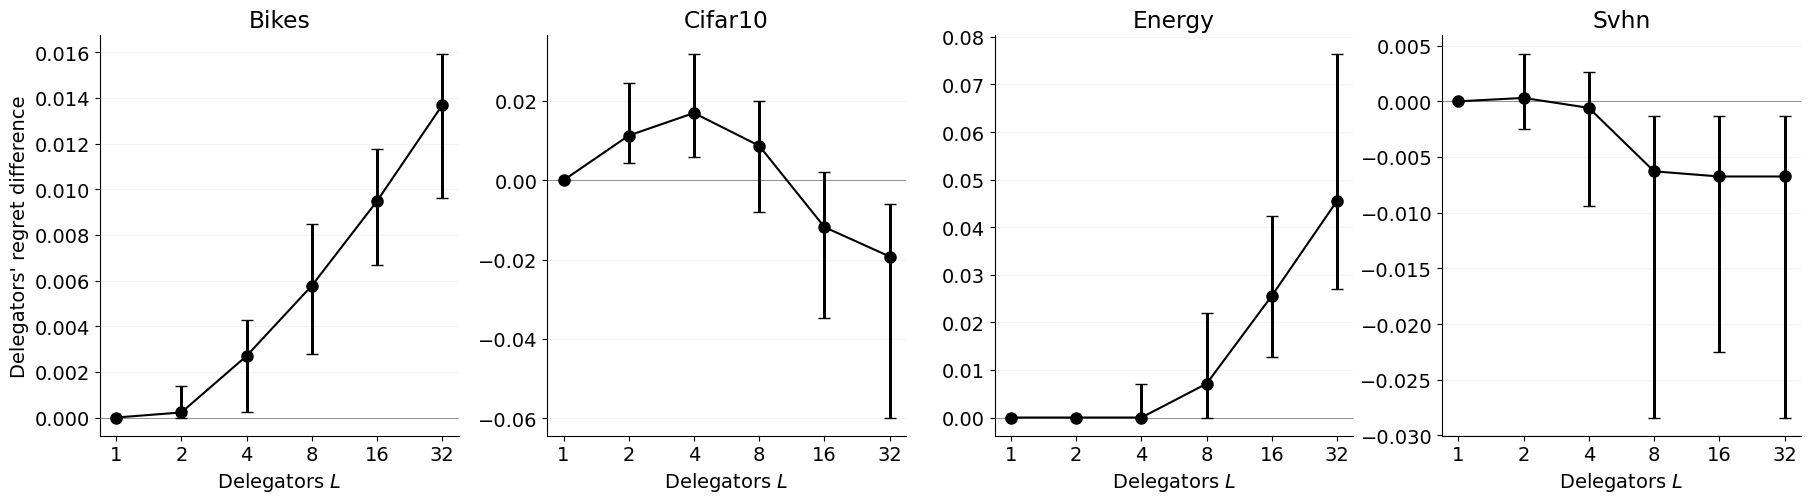

In [ ]:
early_stopping = True
relative = False

run = (
    df
    .pipe(select_early_stopping if early_stopping else select_last)
    .pipe(add_metrics)
)

fig, axs = plt.subplots(1, len(TASKS), sharey=False, figsize=(18, 5))

axs[0].set_ylabel("Delegators' regret difference")

for ax, task in zip(axs.flat, TASKS):
    setup(ax)
    xaxis(ax)
    ax.spines[["right", "top"]].set_visible(False)

    if relative:
        ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))

    run_task = run[run["task"] == task]
    low, mean, high = aggregate_lines_with_base(run_task, "regret", relative=relative, mid_mean=False)
    yerr = np.vstack([mean - low, high - mean])

    x = np.arange(len(var_oi_values))

    ax.plot(x, mean, marker="o", color="black", lw=1.5, ms=8)
    # ax.hlines(low, x - 0.08, x + 0.08, color="black", lw=2)
    # ax.hlines(high, x - 0.08, x + 0.08, color="black", lw=2)
    ax.errorbar(x, mean, yerr=yerr, fmt="o", capsize=4, lw=2, color="black")
    ax.set_title(task.capitalize())

fig.tight_layout(w_pad=2.0)
scale_up_fonts(fig, scale=1.4)

fig.savefig(
    figures_folder / f"{exp_type}_line_regret_diff.pdf"
)

In [65]:
df_metrics[df_metrics["delegators"] == 1]["regret"]

45      0.499453
46      0.473907
47      0.125404
48      0.305590
49      0.268397
          ...   
1246    0.000000
1247    0.001559
1248    0.000000
1249    0.001251
1250    0.000000
Name: regret, Length: 180, dtype: float64

In [64]:
(df_metrics["final_loss"] > df_metrics["final_loss_under_oracle"]).value_counts(normalize=True)

True     0.613492
False    0.386508
Name: proportion, dtype: float64

In [63]:
df_metrics["regret"].describe()

count    1080.000000
mean        0.025806
std         0.055204
min         0.000000
25%         0.000000
50%         0.006944
75%         0.022212
max         0.500787
Name: regret, dtype: float64

In [113]:
def improvment_over_static(g:pd.DataFrame):
    static_i = g["delegators"].idxmin()
    best_i = g[val_loss_col].idxmin()

    improvement = g[val_loss_col][static_i] / g[val_loss_col][best_i]
    best_delegators = g["delegators"][best_i] 

    return pd.Series([improvement, best_delegators], index=["improvement", "best_delegators"])


imp = df.pipe(select_early_stopping).groupby(["task"] + exp_vars)[[val_loss_col, "delegators"]].apply(improvment_over_static).reset_index()
imp["log_improvement"] = np.log(imp["improvement"])
imp.sort_values("improvement").tail(10)

,task,predictors,pwidth,dwidth,improvement,best_delegators,log_improvement
1,Bikes,2,4,8,1.335931,8.0,0.289628
2,Bikes,2,4,16,1.336215,4.0,0.289841
172,Svhn,32,4,8,1.337906,8.0,0.291106
145,Svhn,4,4,8,1.358178,8.0,0.306144
154,Svhn,8,4,8,1.390137,16.0,0.329403
173,Svhn,32,4,16,1.417523,8.0,0.348911
163,Svhn,16,4,8,1.418655,16.0,0.349709
146,Svhn,4,4,16,1.479340,4.0,0.391596
155,Svhn,8,4,16,1.535076,8.0,0.428580
164,Svhn,16,4,16,1.537841,8.0,0.430380


In [120]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import make_pipeline
from sklearn.inspection import permutation_importance

importance_by_task = {}

for task, g in imp.groupby("task"):
    X = g[exp_vars]
    y = np.log(g["improvement"])

    cat_cols = X.select_dtypes(include=["object", "category", "string"]).columns
    num_cols = X.columns.difference(cat_cols)

    model = make_pipeline(
        make_column_transformer(
            (OneHotEncoder(handle_unknown="ignore"), cat_cols),
            ("passthrough", num_cols),
        ),
        RandomForestRegressor(
            n_estimators=500,
            min_samples_leaf=5,
            random_state=0,
        ),
    )

    model.fit(X, y)

    r = permutation_importance(
        model,
        X,
        y,
        n_repeats=20,
        random_state=0,
    )

    importance_by_task[task] = pd.Series(
        r.importances_mean,
        index=X.columns,
        name=task,
    )

importance = (
    pd.concat(importance_by_task, axis=1)
      .T
      .sort_index()
)

importance

,predictors,pwidth,dwidth
Bikes,0.123672,1.475049,0.008011
Cifar10,0.303447,1.087410,0.002030
Energy,0.725814,0.009100,0.622887
Svhn,0.016901,1.717244,0.024471


([<matplotlib.axis.XTick at 0x781c669a4110>,
 [Text(0, 1, 'predictors'), Text(1, 1, 'pwidth'), Text(2, 1, 'dwidth')])

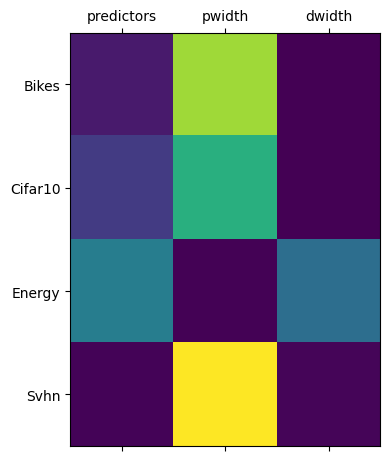

In [126]:
plt.matshow(importance)
plt.yticks(np.arange(len(importance.index)), importance.index)
plt.xticks(np.arange(len(importance.columns)), importance.columns)

In [ ]:
for col in exp_vars:
    display(
        imp.groupby(col)["improvement"]
           .agg(["count", "mean", "median", "std"])
           .sort_values("mean", ascending=False)
    )

,count,mean,median,std
predictors,,,,
16,36,1.114754,1.090376,0.116895
8,36,1.110427,1.087716,0.108780
32,36,1.108697,1.080218,0.103611
4,36,1.107320,1.077799,0.108513
2,36,1.106558,1.063089,0.101941


,count,mean,median,std
pwidth,,,,
4,60,1.173993,1.149258,0.141938
8,60,1.098866,1.106211,0.073478
16,60,1.055795,1.064485,0.042972


,count,mean,median,std
dwidth,,,,
16,60,1.132377,1.106454,0.128492
8,60,1.110659,1.086265,0.102270
4,60,1.085618,1.064485,0.081160


<Axes: ylabel='Density'>

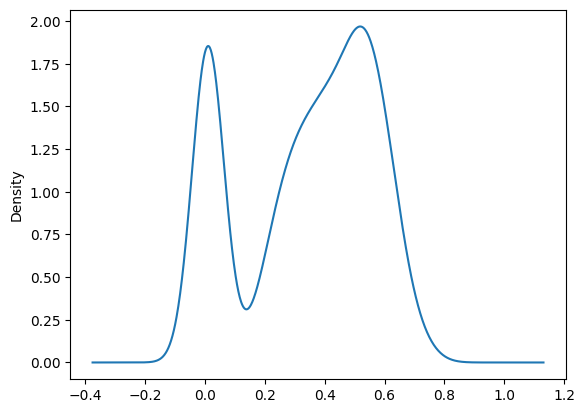

In [ ]:
select_last(df)[train_loss_col].plot.density()

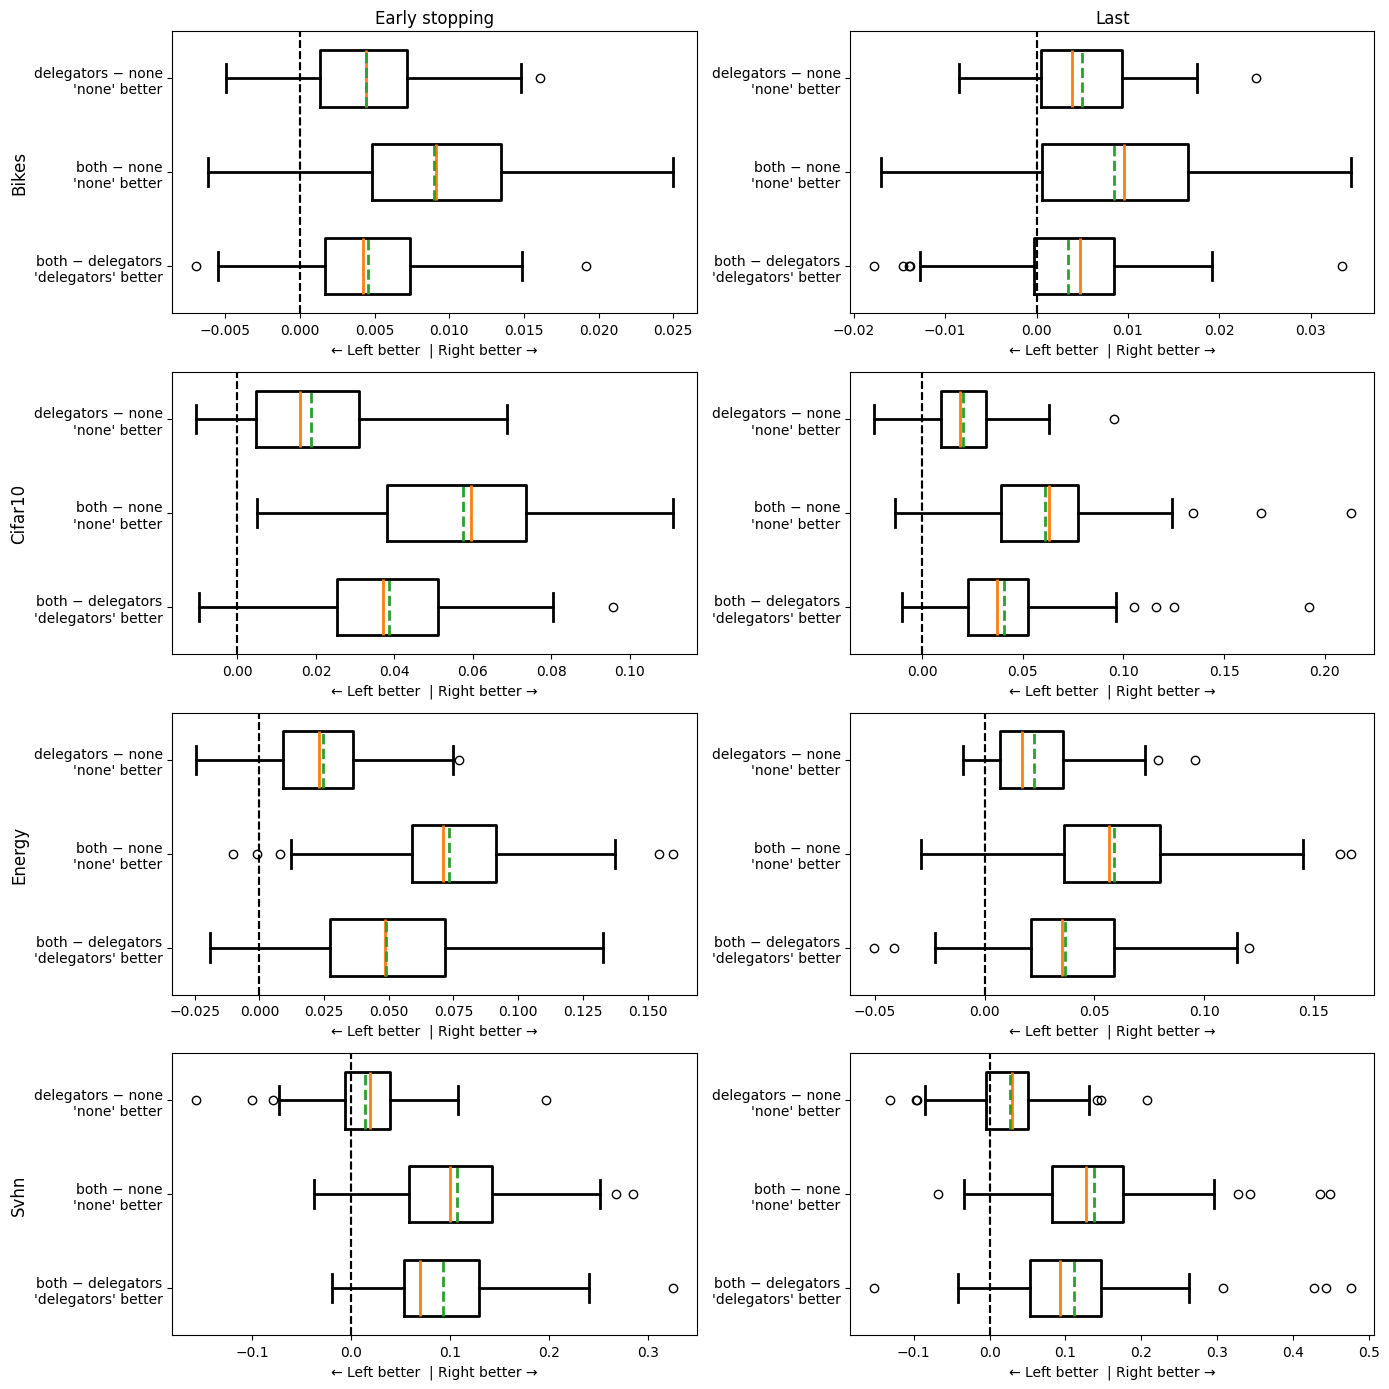

In [98]:
fig, axs = plt.subplots(4, 2, figsize=(14, 14))

axs[0, 0].set_title("Early stopping")
axs[0, 1].set_title("Last")

for i_task, (task, task_df) in enumerate(df.groupby("task")):

    axl, axr = axs[i_task, :]

    task_df.pipe(select_early_stopping).pipe(pair_up).pipe(lambda df: pivot_to_metrics(df, get_metric_col(task))).pipe(lambda df: plot_relative_diff(df, axl))
    task_df.pipe(select_last).pipe(pair_up).pipe(lambda df: pivot_to_metrics(df, get_metric_col(task))).pipe(lambda df: plot_relative_diff(df, axr))

    axl.axvline(0, color="black", linestyle="dashed")
    axr.axvline(0, color="black", linestyle="dashed")

    axl.set_ylabel(task, fontsize=12)

fig.tight_layout()

task
Bikes      0.890112
Cifar10    2.029076
Energy     0.910950
Svhn       2.191658
Name: performance_loss, dtype: float64

### Gradient experiment: is delegator only condition better with increasing sizes of predictors? 

In [27]:
df.columns

Index(['validation_loss', 'validation_load_balancing_loss',
       'validation_performance_loss', 'validation_r2_metric', 'loss',
       'load_balancing_loss', 'performance_loss', 'r2_metric', 'epoch',
       'seed_id', 'run_id', 'task', 'predictors', 'delegators', 'pwidth',
       'dwidth', 'mixing', 'ambiguity', 'validation_accuracy_metric',
       'accuracy_metric'],
      dtype='str')

In [136]:
paired = (
        df
        .pipe(select_early_stopping)
        .pipe(lambda df: pair_up(df, single_task=False))
        .pipe(lambda df: pivot_to_metrics(df, val_loss_col, train_loss_col, "pwidth"))
    )

paired

validation_performance_loss_casted                       \
ambiguity                               both delegators      none   
pair_id                                                             
Bikes_0                             0.044844   0.039321  0.040717   
Bikes_1                             0.052667   0.060908  0.067563   
Bikes_10                            0.042375   0.053217  0.058790   
Bikes_11                            0.046860   0.049247  0.051506   
Bikes_12                            0.040094   0.045790  0.052921   
...                                      ...        ...       ...   
Svhn_95                             0.314889   0.324138  0.364171   
Svhn_96                             0.391190   0.559887  0.610040   
Svhn_97                             0.433113   0.651204  0.628690   
Svhn_98                             0.281850   0.329498  0.352727   
Svhn_99                             0.441615   0.613087  0.701946   

          performance_loss_casted                      pwidth                   
ambiguity                    both delegators      none   both delegators  none  
pair_id                                                                         
Bikes_0                  0.010909   0.009596  0.013638   16.0       16.0  16.0  
Bikes_1                  0.028835   0.040626  0.052704    4.0        4.0   4.0  
Bikes_10                 0.012085   0.026799  0.035503    4.0        4.0   4.0  
Bikes_11                 0.015591   0.023345  0.028436   16.0       16.0  16.0  
Bikes_12                 0.006519   0.014636  0.015955   16.0       16.0  16.0  
...                           ...        ...       ...    ...        ...   ...  
Svhn_95                  0.301535   0.310508  0.355403   16.0       16.0  16.0  
Svhn_96                  0.376905   0.543805  0.615991    4.0        4.0   4.0  
Svhn_97                  0.419733   0.658099  0.633033    4.0        4.0   4.0  
Svhn_98                  0.244506   0.294271  0.335726   16.0       16.0  16.0  
Svhn_99                  0.439587   0.600589  0.704807    4.0        4.0   4.0  

[399 rows x 9 columns]

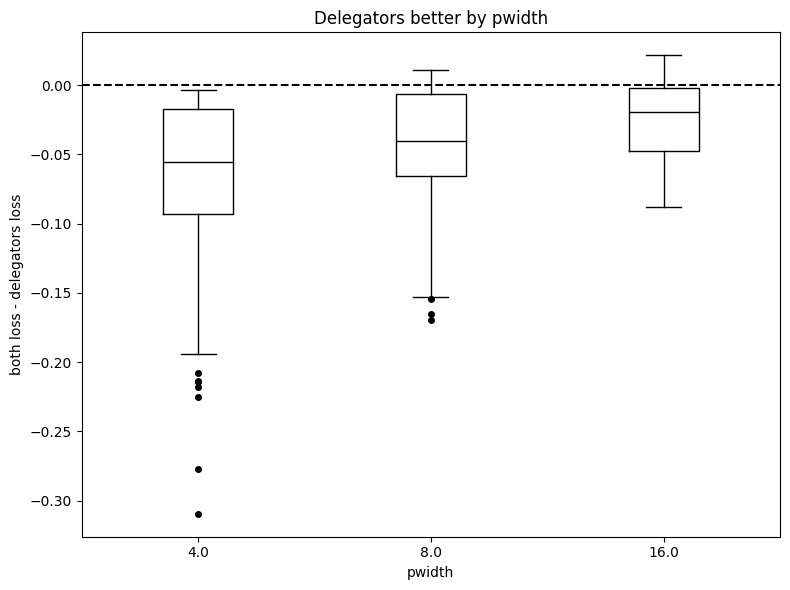

In [138]:
delegators_better = paired[(val_loss_col, "both")] - paired[(val_loss_col, "delegators")]
pwidth = paired[("pwidth", "none")]

grouped = delegators_better.groupby(pwidth, sort=True)

labels = [str(k) for k, _ in grouped]
data = [v.dropna().to_numpy() for _, v in grouped]

fig, ax = plt.subplots(figsize=(8, 6))

ax.boxplot(
    data,
    tick_labels=labels,
    vert=True,
    boxprops=dict(color="black"),
    whiskerprops=dict(color="black"),
    capprops=dict(color="black"),
    medianprops=dict(color="black"),
    flierprops=dict(
        marker="o",
        markeredgecolor="black",
        markerfacecolor="black",
        markersize=4,
    ),
)

ax.axhline(0, color="black", linestyle="dashed")
ax.set_xlabel("pwidth")
ax.set_ylabel("both loss - delegators loss")
ax.set_title("Delegators better by pwidth")

plt.tight_layout()
plt.show()

Opa we can see clear trend supporting theory: as the predictors get more capable (perfect intrepolators) the delegator condition becomes more viable. The theory that one should not explicitly maximize variance (condition "both") mostly applies when the predictors are perfect interpolators.

Lets check it a bit more precisely with a performance training loss

Text(0, 0.5, 'Delegators better')

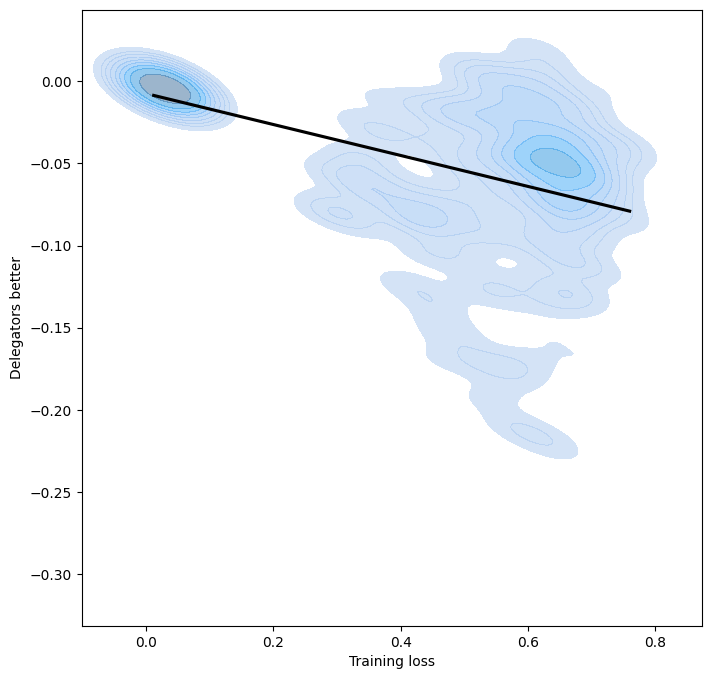

In [139]:
import seaborn as sns

training_loss = paired["performance_loss_casted"]["none"]

fig, ax = plt.subplots(figsize=(8, 8))

sns.kdeplot(x=training_loss, y=delegators_better, fill=True, alpha=.5, ax=ax, bw_adjust=0.4)
sns.regplot(x=training_loss, y=delegators_better, scatter=False, ci=None, ax=ax, color="black")

ax.set_xlabel("Training loss")
ax.set_ylabel("Delegators better")

In [102]:
df.groupby("run_id").size()

run_id
1      21000
2      21000
3      21000
4      21000
5      21000
       ...  
296    21000
297    21000
298    21000
299    21000
300    21000
Length: 300, dtype: int64